# Задание 1.  Классификатор 128×128

Разархивируем архив с данными

In [1]:
!unzip -q tiny-imagenet-200.zip

Импорт библиотек

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random
import matplotlib.pyplot as plt

Dataset

In [3]:
class TinyImageNet128(Dataset):
    def __init__(self, root_dir, classes, split="train", transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.images = []
        self.labels = []

        self.class_to_idx = {cls:i for i, cls in enumerate(classes)}

        if split == "train":
            for cls in classes:
                cls_dir = os.path.join(root_dir, "train", cls, "images")
                for img_name in os.listdir(cls_dir):
                    self.images.append(os.path.join(cls_dir, img_name))
                    self.labels.append(self.class_to_idx[cls])
        elif split == "val":
            ann_path = os.path.join(root_dir, "val", "val_annotations.txt")
            img_dir = os.path.join(root_dir, "val", "images")
            with open(ann_path) as f:
                for line in f:
                    img_name, cls_id, *_ = line.strip().split("\t")
                    if cls_id in classes:
                        self.images.append(os.path.join(img_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_id])
        else:
            raise ValueError("split must be 'train' or 'val'")

        print(f"{split} samples loaded: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label


Трансформация данных

In [4]:
train_transform = transforms.Compose([
    transforms.Resize(144),             # Resize, потом центр/рандом кроп
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
])


Загружаем данные

In [5]:
selected_classes = [
    'n02769748','n02099712','n07695742','n02056570','n02281406',
    'n01774750','n02509815','n03983396','n07753592','n04254777'
]

train_dataset = TinyImageNet128("tiny-imagenet-200", selected_classes, split="train", transform=train_transform)
val_dataset   = TinyImageNet128("tiny-imagenet-200", selected_classes, split="val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

train samples loaded: 5000
val samples loaded: 500


Модель (модификация из пердыдущего задания)

In [6]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, act_fn=nn.ReLU):
        super().__init__()
        self.act = act_fn(inplace=True) if act_fn in [nn.ReLU, nn.LeakyReLU] else act_fn()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        out = self.act(out)
        return out

class ResNet128(nn.Module):
    def __init__(self, num_classes=10, channels=[32,64,128,256], blocks_per_layer=[1,1,1,1], act_fn=nn.ReLU):
        super().__init__()
        self.act = act_fn if act_fn is not None else nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(3, channels[0], kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(channels[0])
        self.relu = self.act()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(channels[0], channels[0], blocks_per_layer[0], stride=1)
        self.layer2 = self._make_layer(channels[0], channels[1], blocks_per_layer[1], stride=2)
        self.layer3 = self._make_layer(channels[1], channels[2], blocks_per_layer[2], stride=2)
        self.layer4 = self._make_layer(channels[2], channels[3], blocks_per_layer[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(channels[3], num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride, act_fn=self.act)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1, act_fn=self.act))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

Количество параметров в модели

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet128(num_classes=10).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")


Total parameters: 1.23M


Обучение

In [8]:
# --------------------------
# Optimizer, Loss
# --------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --------------------------
# Функции для обучения
# --------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss/total, correct/total

# --------------------------
# Обучение
# --------------------------
epochs = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch}/{epochs} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")



Epoch 1/20 | Train Loss: 1.9342, Acc: 0.3052 | Val Loss: 2.2099, Acc: 0.2700
Epoch 2/20 | Train Loss: 1.6929, Acc: 0.4154 | Val Loss: 2.5835, Acc: 0.3140
Epoch 3/20 | Train Loss: 1.5482, Acc: 0.4624 | Val Loss: 2.1756, Acc: 0.3900
Epoch 4/20 | Train Loss: 1.4342, Acc: 0.5070 | Val Loss: 1.6240, Acc: 0.4720
Epoch 5/20 | Train Loss: 1.2953, Acc: 0.5662 | Val Loss: 2.3440, Acc: 0.3640
Epoch 6/20 | Train Loss: 1.2297, Acc: 0.5806 | Val Loss: 1.6084, Acc: 0.4500
Epoch 7/20 | Train Loss: 1.1624, Acc: 0.6008 | Val Loss: 1.2481, Acc: 0.5800
Epoch 8/20 | Train Loss: 1.0936, Acc: 0.6366 | Val Loss: 1.3475, Acc: 0.5480
Epoch 9/20 | Train Loss: 1.0642, Acc: 0.6402 | Val Loss: 1.3622, Acc: 0.5520
Epoch 10/20 | Train Loss: 1.0005, Acc: 0.6588 | Val Loss: 1.5307, Acc: 0.5140
Epoch 11/20 | Train Loss: 0.9664, Acc: 0.6766 | Val Loss: 1.5035, Acc: 0.5440
Epoch 12/20 | Train Loss: 0.9120, Acc: 0.6918 | Val Loss: 1.2107, Acc: 0.6180
Epoch 13/20 | Train Loss: 0.8603, Acc: 0.7096 | Val Loss: 1.2708, Acc: 0.

Построение графиков

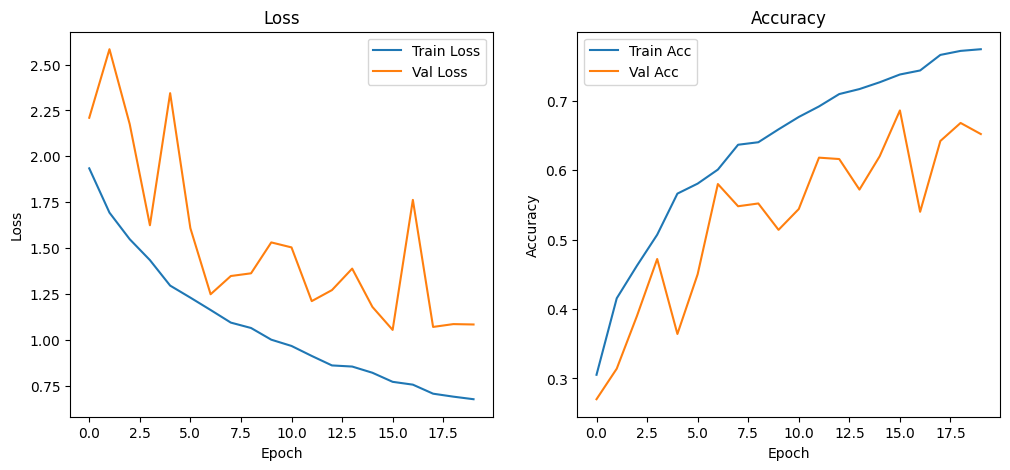

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Обучение с сохранением лучшей модели

In [10]:
best_val_acc = 0.0
best_model_path = "resnet128_best.pth"

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}/{epochs} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Сохраняем модель если лучше валид. точность
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> New best model saved with val_acc: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.6431, Acc: 0.7822 | Val Loss: 1.0337, Acc: 0.6840
  -> New best model saved with val_acc: 0.6840
Epoch 2/20 | Train Loss: 0.5943, Acc: 0.8042 | Val Loss: 1.0796, Acc: 0.6720
Epoch 3/20 | Train Loss: 0.5711, Acc: 0.8078 | Val Loss: 0.9977, Acc: 0.6980
  -> New best model saved with val_acc: 0.6980
Epoch 4/20 | Train Loss: 0.5658, Acc: 0.8016 | Val Loss: 1.2135, Acc: 0.6220
Epoch 5/20 | Train Loss: 0.5287, Acc: 0.8262 | Val Loss: 1.3377, Acc: 0.5980
Epoch 6/20 | Train Loss: 0.5378, Acc: 0.8208 | Val Loss: 0.9457, Acc: 0.7160
  -> New best model saved with val_acc: 0.7160
Epoch 7/20 | Train Loss: 0.4767, Acc: 0.8382 | Val Loss: 1.0479, Acc: 0.7080
Epoch 8/20 | Train Loss: 0.4744, Acc: 0.8354 | Val Loss: 1.1639, Acc: 0.6400
Epoch 9/20 | Train Loss: 0.4525, Acc: 0.8450 | Val Loss: 1.0527, Acc: 0.6660
Epoch 10/20 | Train Loss: 0.4694, Acc: 0.8368 | Val Loss: 0.8952, Acc: 0.7360
  -> New best model saved with val_acc: 0.7360
Epoch 11/20 | Train Loss: 0.4335, Acc: 0.

Загрузка лучшей модели

In [11]:
best_model = ResNet128(num_classes=10).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

ResNet128(
  (conv1): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (act): ReLU(inplace=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (act): ReLU(inplace=True)
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

Оценка модели

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = best_model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=selected_classes))

print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

Classification Report:
              precision    recall  f1-score   support

   n02769748       0.66      0.74      0.70        50
   n02099712       0.58      0.88      0.70        50
   n07695742       0.67      0.66      0.67        50
   n02056570       0.78      0.84      0.81        50
   n02281406       0.84      0.94      0.89        50
   n01774750       0.79      0.74      0.76        50
   n02509815       0.87      0.90      0.88        50
   n03983396       0.73      0.60      0.66        50
   n07753592       0.80      0.56      0.66        50
   n04254777       0.94      0.64      0.76        50

    accuracy                           0.75       500
   macro avg       0.77      0.75      0.75       500
weighted avg       0.77      0.75      0.75       500

Confusion Matrix:
[[37  6  1  0  0  1  1  3  1  0]
 [ 1 44  1  2  0  0  1  0  1  0]
 [ 4  6 33  1  0  2  1  1  2  0]
 [ 1  6  0 42  0  0  0  1  0  0]
 [ 0  0  1  0 47  1  0  0  0  1]
 [ 0  5  2  4  0 37  2  0  0  0]
 [

Визуализация 10 случайных примеров

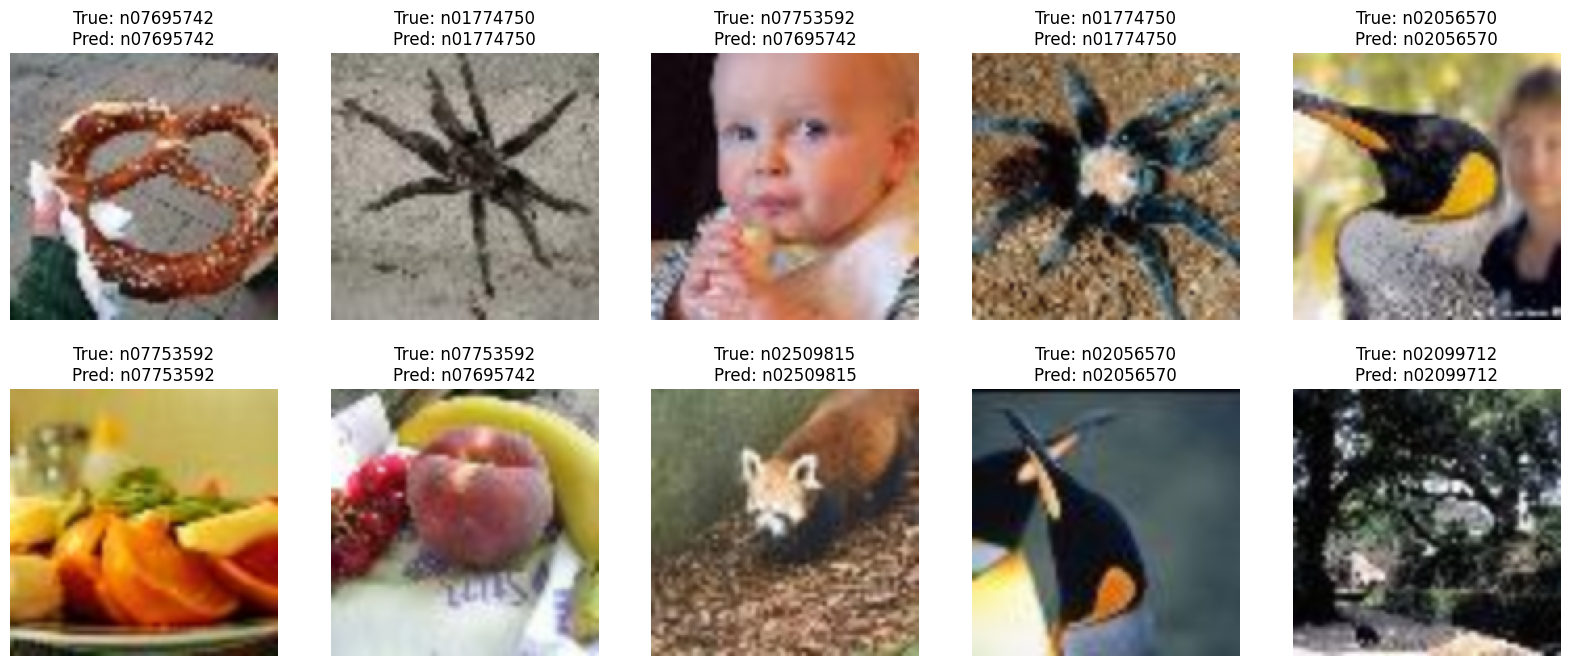

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20,8))
for i, ax in enumerate(axes.flatten()):
    idx = random.randint(0, len(val_dataset)-1)
    img, label = val_dataset[idx]
    pred = torch.argmax(best_model(img.unsqueeze(0).to(device)), dim=1).item()

    ax.imshow(img.permute(1,2,0))
    ax.set_title(f"True: {selected_classes[label]}\nPred: {selected_classes[pred]}")
    ax.axis("off")
plt.show()


# 2 задание. Базовая U-Net на "Луне"

Разархивируем архив

In [14]:
!unzip -q MOON_SEGMENTATION_BINARY.zip

In [15]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

In [16]:
def denormalize(img_tensor):
    """Денормализация изображения для визуализации"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1)

Датасет

In [17]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset

class MoonSegmentationDataset(Dataset):
    def __init__(
        self,
        root_dir,
        image_folder="render",
        mask_folder="ground",
        image_ids=None,
        augmentation=None,
        preprocessing=None
    ):
        """
        root_dir: путь к MOON_SEGMENTATION_BINARY
        image_folder: папка с изображениями (render)
        mask_folder: папка с масками (ground)
        image_ids: список id (например ["0001", "0002"])
        augmentation: albumentations.Compose
        preprocessing: albumentations.Compose
        """

        self.root_dir = root_dir
        self.image_folder = image_folder
        self.mask_folder = mask_folder
        self.augmentation = augmentation
        self.preprocessing = preprocessing

        self.images_dir = os.path.join(root_dir, "images", image_folder)
        self.masks_dir = os.path.join(root_dir, "images", mask_folder)

        if image_ids is None:
            all_images = os.listdir(self.images_dir)
            self.image_ids = [
                img.replace(".png", "")
                for img in all_images if img.endswith(".png")
            ]
        else:
            self.image_ids = image_ids

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        mask_id = image_id.replace('render', '') if 'render' in image_id else image_id

        image_path = os.path.join(
            self.images_dir, f"{image_id}.png"
        )
        mask_path = os.path.join(
            self.masks_dir, f"ground{mask_id}.png"
        )

        # --- Load ---
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            raise FileNotFoundError(f"Missing file: {image_path} or {mask_path}")

        # BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Бинаризация маски
        mask = (mask > 0).astype(np.float32)

        # --- Augmentations ---
        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        # --- Preprocessing ---
        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed["image"], processed["mask"]

        return image, mask


Аугментации и загрузчики

In [18]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

train_augmentation = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

preprocessing = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_augmentation = A.Compose([
    A.Resize(128, 128),
])

# Путь к данным
MOON_DATA_PATH = "MOON_SEGMENTATION_BINARY/"

images_dir = os.path.join(MOON_DATA_PATH, 'images', 'render')
all_images = [img.replace('.png', '') for img in os.listdir(images_dir) if img.endswith('.png')]

print(f"Всего изображений: {len(all_images)}")

train_ids, val_ids = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Train: {len(train_ids)} изображений")
print(f"Val: {len(val_ids)} изображений")


train_dataset = MoonSegmentationDataset(
    root_dir=MOON_DATA_PATH,
    image_folder='render',
    mask_folder='ground',
    image_ids=train_ids,
    augmentation=train_augmentation,
    preprocessing=preprocessing
)

val_dataset = MoonSegmentationDataset(
    root_dir=MOON_DATA_PATH,
    image_folder='render',
    mask_folder='ground',
    image_ids=val_ids,
    augmentation=val_augmentation,
    preprocessing=preprocessing
)

batch_size = 10

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

print(f"Батчей в train: {len(train_loader)}")
print(f"Батчей в val: {len(val_loader)}")


Всего изображений: 1000
Train: 800 изображений
Val: 200 изображений
Батчей в train: 80
Батчей в val: 20


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Примеры изображений

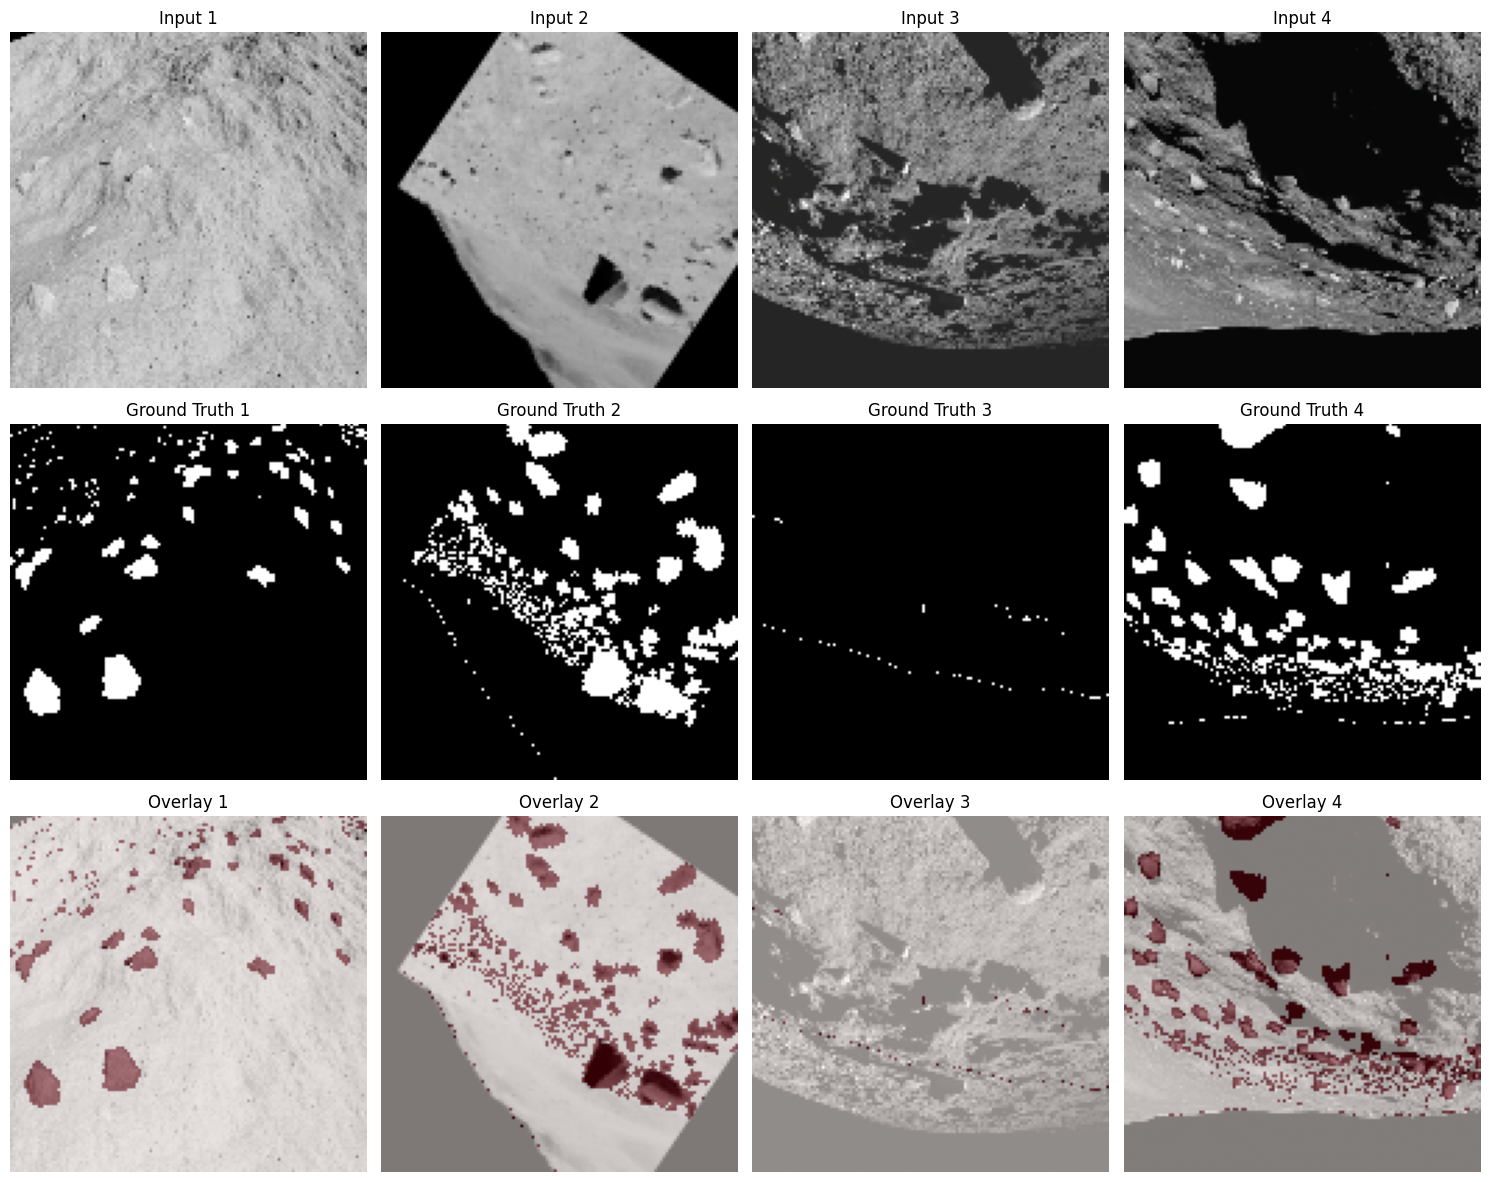

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
for i in range(4):
    img, mask = train_dataset[i*10]

    img_display = denormalize(img)
    img_display = img_display.permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    axes[0, i].imshow(img_display)
    axes[0, i].set_title(f'Input {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask.squeeze(), cmap='gray')
    axes[1, i].set_title(f'Ground Truth {i+1}')
    axes[1, i].axis('off')

    axes[2, i].imshow(img_display)
    axes[2, i].imshow(mask.squeeze(), cmap='Reds', alpha=0.5)
    axes[2, i].set_title(f'Overlay {i+1}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

Базовая U-Net на "Луне"

In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [21]:
class UNet(nn.Module):

    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()

        self.encoder_blocks = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        prev_channels = in_channels
        for feature in features:
            self.encoder_blocks.append(DoubleConv(prev_channels, feature))
            prev_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.decoder_blocks.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder_blocks.append(
                DoubleConv(feature * 2, feature)
            )

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

        total_params = sum(p.numel() for p in self.parameters())
        print(f"Параметров: {total_params:,}")
        print(f"Уровней encoder: {len(features)}")
        print(f"Конфигурация каналов: {features}")

    def forward(self, x):

        skip_connections = []

        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.decoder_blocks), 2):
            x = self.decoder_blocks[idx](x)

            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:],
                                mode='bilinear', align_corners=True)

            x = torch.cat([skip_connection, x], dim=1)

            x = self.decoder_blocks[idx + 1](x)

        output = self.final_conv(x)

        return output


model = UNet(in_channels=3, out_channels=1, features=[64, 128, 256, 512])
total_params = sum(p.numel() for p in model.parameters())
test_input = torch.randn(1, 3, 256, 256)
test_output = model(test_input)

print(f"   Вход:  {test_input.shape}")
print(f"   Выход: {test_output.shape}")

Параметров: 31,043,521
Уровней encoder: 4
Конфигурация каналов: [64, 128, 256, 512]
   Вход:  torch.Size([1, 3, 256, 256])
   Выход: torch.Size([1, 1, 256, 256])


Функции потерь и метрики для сегментации

In [22]:
class DiceLoss(nn.Module):
    """
    Dice Loss для бинарной сегментации

    Dice = 2 * |X ∩ Y| / (|X| + |Y|)
    """
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)

        # Flatten
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        # Dice coefficient
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)

        # Dice loss
        return 1 - dice


class CombinedLoss(nn.Module):

    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, predictions, targets):
        bce_loss = self.bce(predictions, targets)
        dice_loss = self.dice(predictions, targets)

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


def dice_coefficient(predictions, targets, threshold=0.5, smooth=1e-6):

    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    dice = (2. * intersection + smooth) / (predictions.sum() + targets.sum() + smooth)

    return dice.item()


def iou_score(predictions, targets, threshold=0.5, smooth=1e-6):

    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()


def pixel_accuracy(predictions, targets, threshold=0.5):

    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()
    correct = (predictions == targets).float().sum()
    total = targets.numel()

    return (correct / total).item()

Настройка обучения

In [23]:
def train_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc= 0.0

    pbar = tqdm(train_loader, desc="Training")

    for images, masks in pbar:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            dice = dice_coefficient(outputs, masks)
            iou = iou_score(outputs, masks)
            acc = pixel_accuracy(outputs, masks)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou
        running_acc += acc

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}',
            'acc': f'{acc:.4f}'
        })

    avg_loss = running_loss / len(train_loader)
    avg_dice = running_dice / len(train_loader)
    avg_iou = running_iou / len(train_loader)
    avg_acc = running_acc / len(train_loader)

    return avg_loss, avg_dice, avg_iou, avg_acc


def validate_epoch(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0

    pbar = tqdm(val_loader, desc="Validation")

    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            dice = dice_coefficient(outputs, masks)
            iou = iou_score(outputs, masks)
            acc = pixel_accuracy(outputs, masks)


            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            running_acc += acc

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}',
                'acc': f'{acc:.4f}'
            })

    avg_loss = running_loss / len(val_loader)
    avg_dice = running_dice / len(val_loader)
    avg_iou = running_iou / len(val_loader)
    avg_acc = running_acc / len(val_loader)

    return avg_loss, avg_dice, avg_iou, avg_acc

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=20, save_path='best_unet.pth'):

    model = model.to(device)

    history = {
        'train_loss': [],
        'train_dice': [],
        'train_iou': [],
        'train_acc': [],
        'val_loss': [],
        'val_dice': [],
        'val_iou': [],
        'val_acc': [],
        'lr': []
    }

    best_val_dice = 0.0

    for epoch in range(num_epochs):
        print(f"Эпоха {epoch+1}/{num_epochs}")

        # Здесь происходит основное обучение
        train_loss, train_dice, train_iou, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Валидация
        val_loss, val_dice, val_iou, val_acc = validate_epoch(
            model, val_loader, criterion, device
        )

        # Обновляем learning rate (проверяем на )
        if scheduler is not None:
            scheduler.step(val_dice)
            current_lr = optimizer.param_groups[0]['lr']
        else:
            current_lr = optimizer.param_groups[0]['lr']

        # Сохраняем всю нашу историю
        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['train_iou'].append(train_iou)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Выводим результаты
        print(f"\n Результаты эпохи {epoch+1}:")
        print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}, Pixel: {train_acc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}, Pixel: {val_acc:.4f}")
        print(f"  LR: {current_lr:.6f}")

        # Сохраняем лучшую модел, можно сохранять по метрике или loss
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_dice': val_dice,
                'val_iou': val_iou,
                'val_acc': val_acc
            }, save_path)
            print(f"  Сохранена лучшая модель! Dice: {val_dice:.4f}")

    print(f"Лучший Val Dice: {best_val_dice:.4f}")

    return history

Запуск обучения

In [25]:
# Настройка обучения
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Используем устройство: {device}")

model = UNet(in_channels=3, out_channels=1, features=[32, 64, 128, 256])

# Функция потерь (комбинированная BCE + Dice)
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

# Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Планировщик learning rate (уменьшаем lr при плато)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

NUM_EPOCHS = 10

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    save_path='best_moon_unet.pth'
)

  Используем устройство: cpu
Параметров: 7,765,985
Уровней encoder: 4
Конфигурация каналов: [32, 64, 128, 256]
Эпоха 1/10


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.35s/it, loss=0.6242, dice=0.5221, iou=0.3533, acc=0.8831]



 Результаты эпохи 1:
  Train - Loss: 0.7054, Dice: 0.3511, IoU: 0.2158, Pixel: 0.7432
  Val   - Loss: 0.6436, Dice: 0.4461, IoU: 0.2884, Pixel: 0.8738
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.4461
Эпоха 2/10


Validation: 100%|██████████| 20/20 [00:27<00:00,  1.37s/it, loss=0.5675, dice=0.5791, iou=0.4075, acc=0.9016]



 Результаты эпохи 2:
  Train - Loss: 0.6310, Dice: 0.4474, IoU: 0.2909, Pixel: 0.8795
  Val   - Loss: 0.5920, Dice: 0.5065, IoU: 0.3409, Pixel: 0.8990
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.5065
Эпоха 3/10


...


 Результаты эпохи 8:
  Train - Loss: 0.5206, Dice: 0.5385, IoU: 0.3713, Pixel: 0.8954
  Val   - Loss: 0.4985, Dice: 0.5810, IoU: 0.4121, Pixel: 0.8990
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.5810
Эпоха 9/10


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.34s/it, loss=0.4537, dice=0.6491, iou=0.4805, acc=0.9056]



 Результаты эпохи 9:
  Train - Loss: 0.5062, Dice: 0.5475, IoU: 0.3798, Pixel: 0.8984
  Val   - Loss: 0.4849, Dice: 0.5845, IoU: 0.4162, Pixel: 0.9019
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.5845
Эпоха 10/10


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.32s/it, loss=0.4385, dice=0.6423, iou=0.4731, acc=0.9001]


 Результаты эпохи 10:
  Train - Loss: 0.4984, Dice: 0.5381, IoU: 0.3713, Pixel: 0.8969
  Val   - Loss: 0.4645, Dice: 0.5900, IoU: 0.4214, Pixel: 0.9098
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.5900
Лучший Val Dice: 0.5900


Визуализация результатов обучения

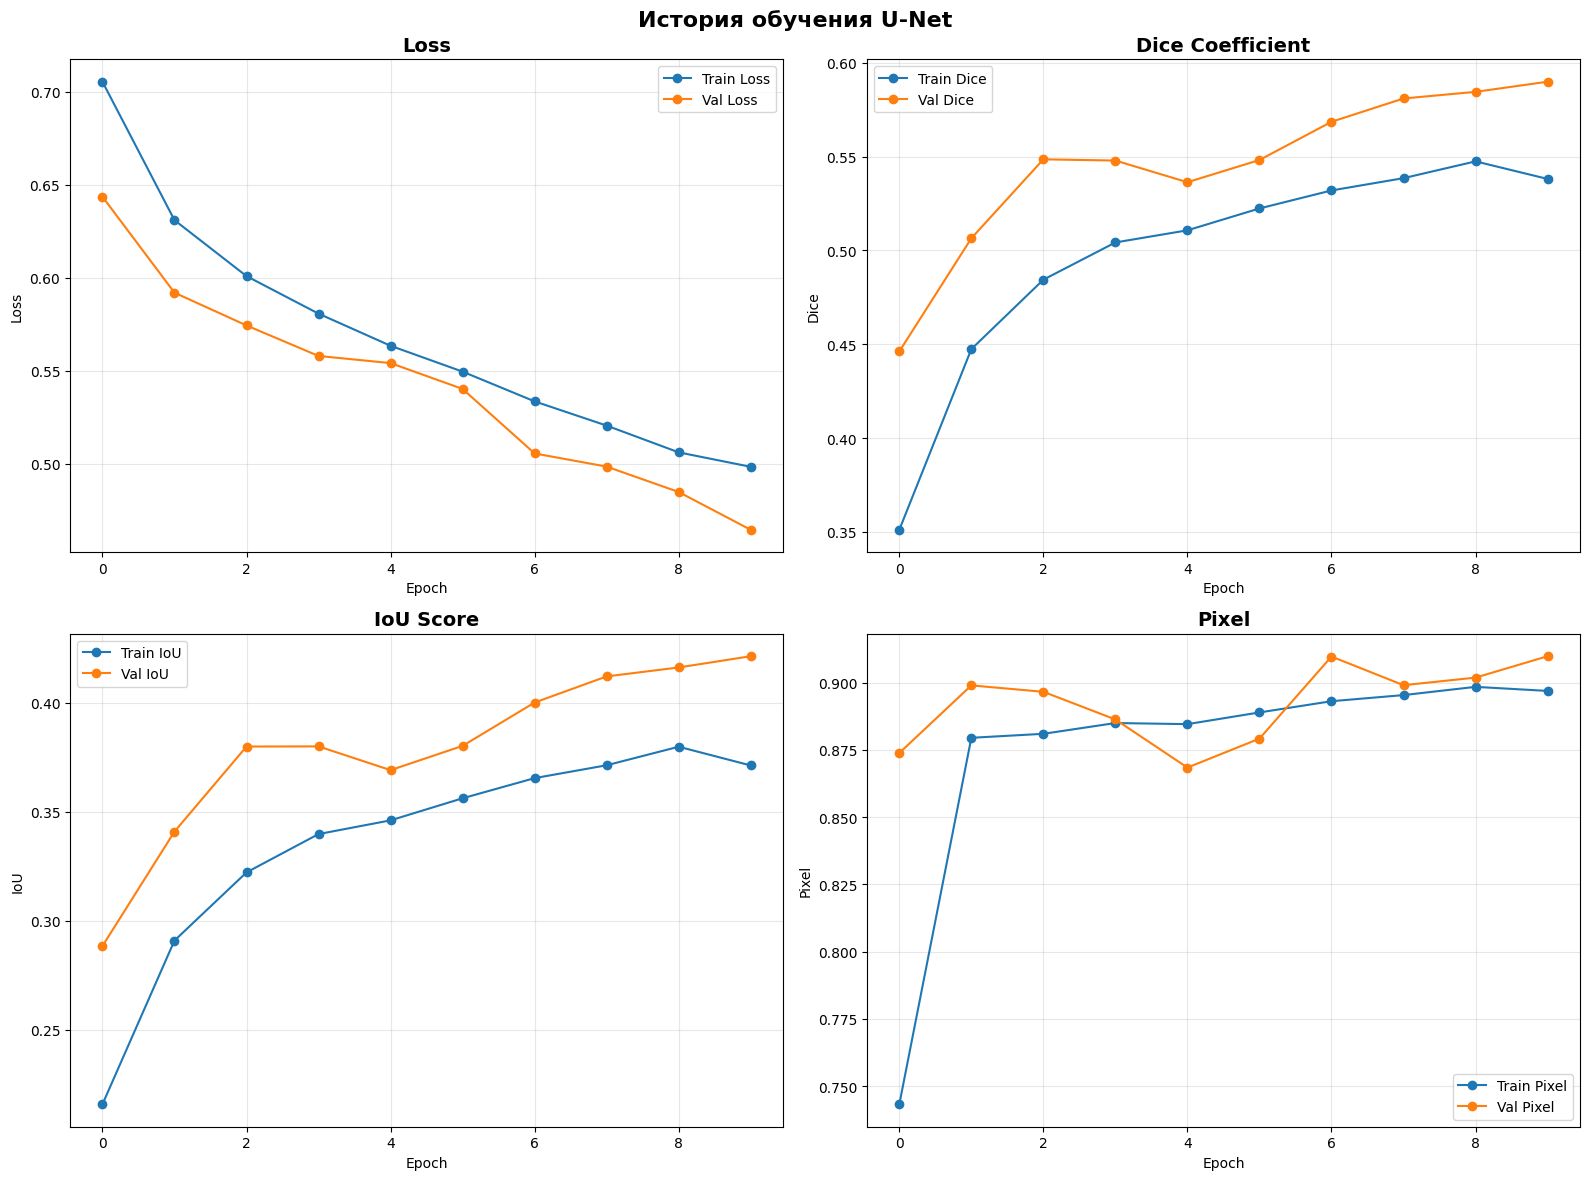

Train Loss: 0.4984
Val Loss: 0.4645
Train Dice: 0.5381
Val Dice: 0.5900
Train IoU: 0.3713
Val IoU: 0.4214
Val Accuracy: 0.9098


In [26]:
def plot_training_history(history):

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Dice Coefficient
    axes[0, 1].plot(history['train_dice'], label='Train Dice', marker='o')
    axes[0, 1].plot(history['val_dice'], label='Val Dice', marker='o')
    axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # IoU Score
    axes[1, 0].plot(history['train_iou'], label='Train IoU', marker='o')
    axes[1, 0].plot(history['val_iou'], label='Val IoU', marker='o')
    axes[1, 0].set_title('IoU Score', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 1].plot(history['train_acc'], label='Train Pixel', marker='o')
    axes[1, 1].plot(history['val_acc'], label='Val Pixel', marker='o')
    axes[1, 1].set_title('Pixel', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Pixel')
    # axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('История обучения U-Net', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


    print(f"Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"Train Dice: {history['train_dice'][-1]:.4f}")
    print(f"Val Dice: {history['val_dice'][-1]:.4f}")
    print(f"Train IoU: {history['train_iou'][-1]:.4f}")
    print(f"Val IoU: {history['val_iou'][-1]:.4f}")
    print(f"Val Accuracy: {history['val_acc'][-1]:.4f}")

plot_training_history(history)

Визуализация предсказаний

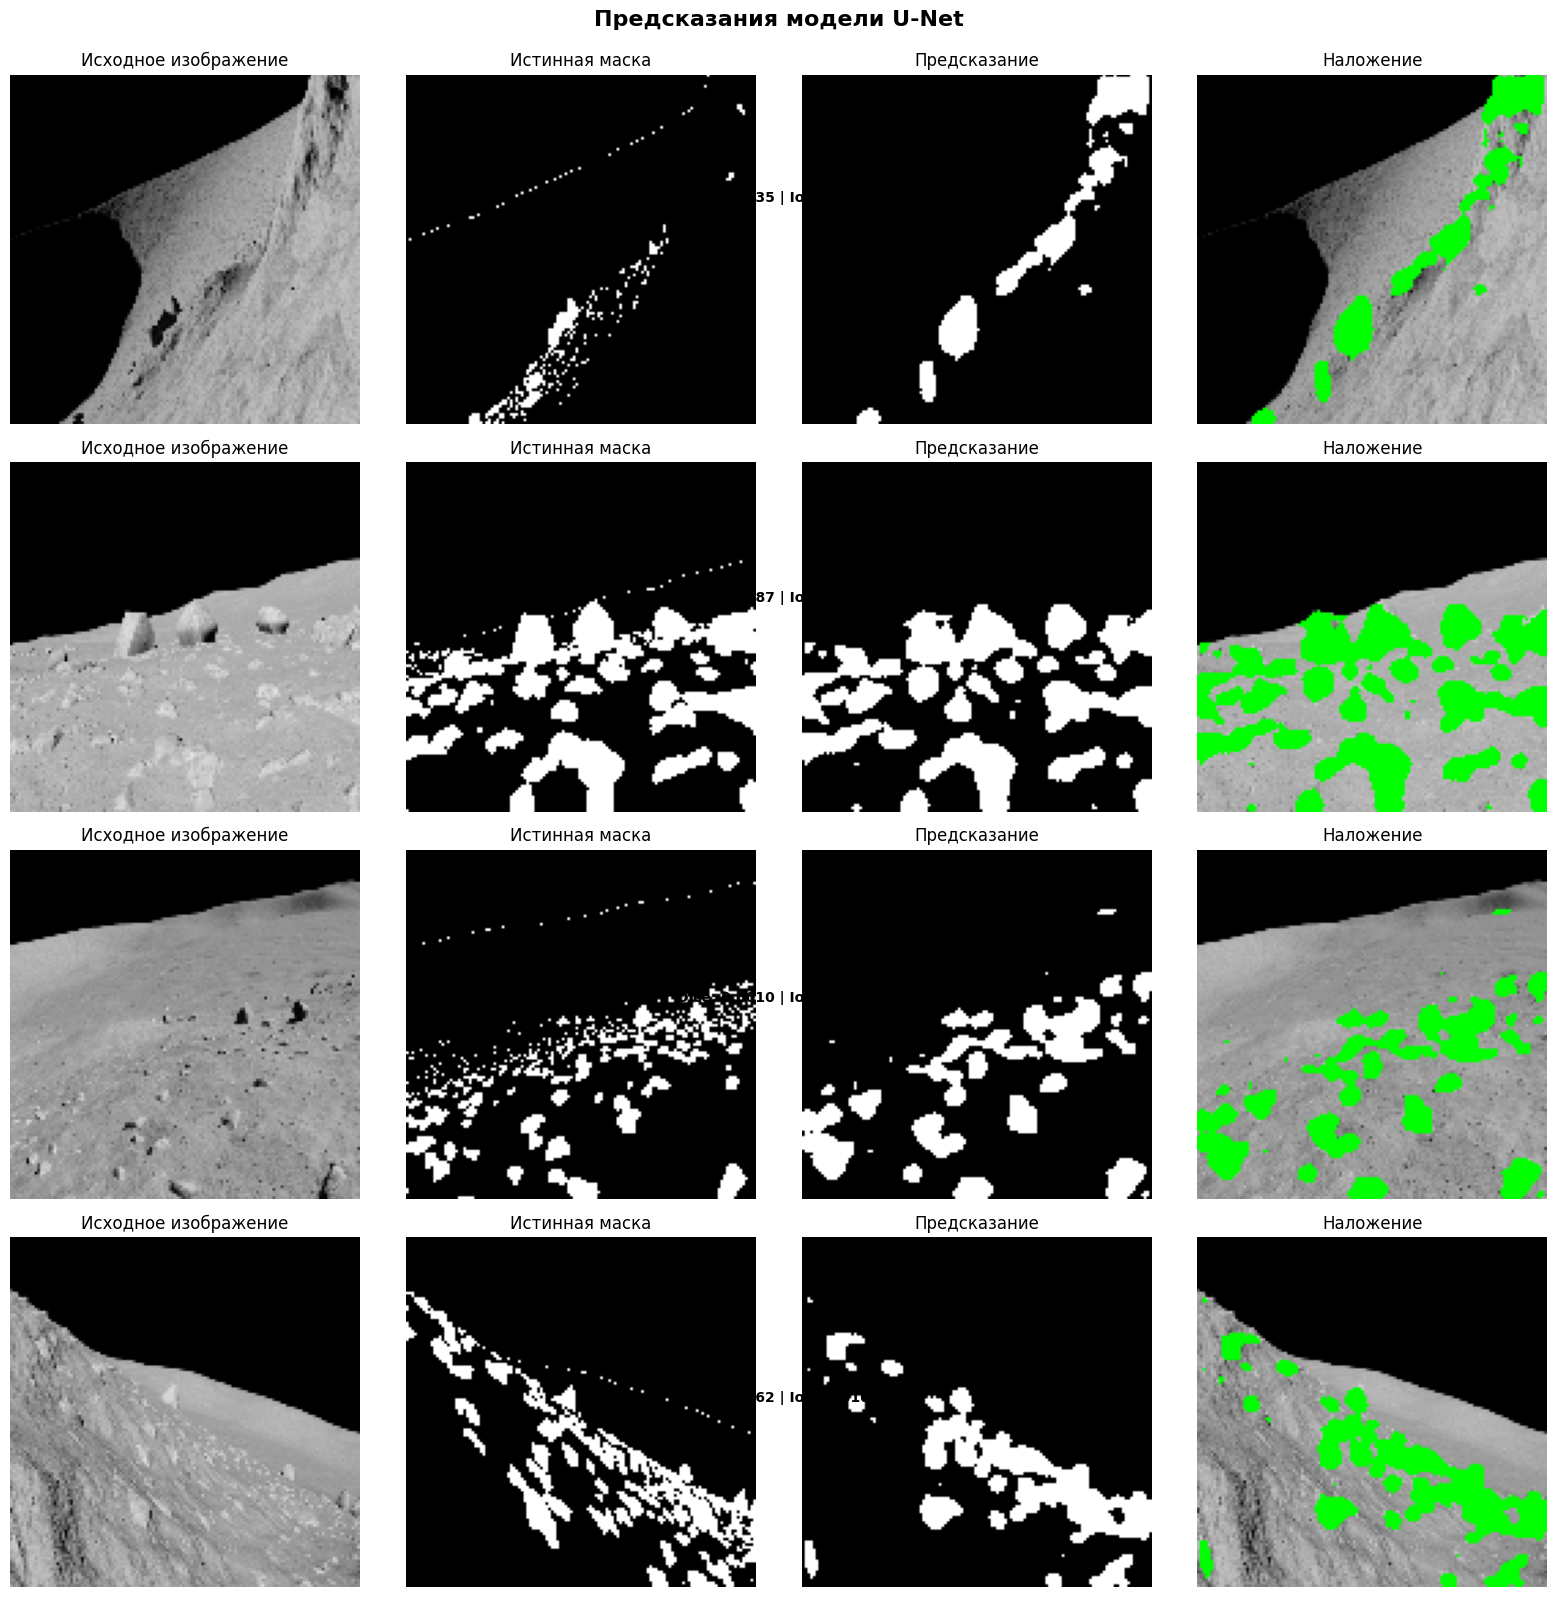

In [27]:
def visualize_predictions(model, dataloader, device, num_samples=4):

    model.eval()

    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = torch.sigmoid(outputs)
        predictions = (predictions > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    predictions = predictions.cpu()

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    for i in range(min(num_samples, len(images))):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        mask_true = masks[i, :,:].numpy()
        mask_pred = predictions[i, 0].numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Исходное изображение', fontsize=12)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_true, cmap='gray')
        axes[i, 1].set_title('Истинная маска', fontsize=12)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(mask_pred, cmap='gray')
        axes[i, 2].set_title('Предсказание', fontsize=12)
        axes[i, 2].axis('off')

        overlay = img.copy()
        overlay[mask_pred > 0.5] = [0, 1, 0]

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Наложение', fontsize=12)
        axes[i, 3].axis('off')

        dice = dice_coefficient(outputs[i:i+1], masks[i:i+1])
        iou = iou_score(outputs[i:i+1], masks[i:i+1])

        fig.text(0.5, 1 - (i + 0.5) / num_samples,
                f'Dice: {dice:.4f} | IoU: {iou:.4f}',
                ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('Предсказания модели U-Net', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, device, num_samples=4)

# Задание 3. U-Net с бэкбоном из классификатора

In [28]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

Модель

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetWithBackbone(nn.Module):
    """
    U-Net с энкодером из классификатора (final_model)

    Варианты:
    - freeze_encoder=True  -> Variant A: заморозка энкодера
    - freeze_encoder=False -> Variant B: тонкая настройка
    """
    def __init__(self, backbone, out_channels=1, freeze_encoder=True):
        super().__init__()

        self.backbone = backbone

        # Заморозка энкодера
        if freeze_encoder:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Срезаем GAP и FC головы
        # Предполагается, что backbone.forward вернет x после layer4
        # или создаём метод backbone.features(x)

        # Декодер U-Net
        self.pool = nn.MaxPool2d(2)
        # Предположим, что финальная конфигурация каналов энкодера:
        # [64, 128, 256, 512]
        enc_channels = [64, 128, 256, 512]
        dec_channels = list(reversed(enc_channels))

        self.bottleneck = DoubleConv(enc_channels[-1], enc_channels[-1]*2)

        self.up_convs = nn.ModuleList()
        self.double_convs = nn.ModuleList()
        for ch in dec_channels:
            self.up_convs.append(nn.ConvTranspose2d(ch*2, ch, kernel_size=2, stride=2))
            self.double_convs.append(DoubleConv(ch*2, ch))

        self.final_conv = nn.Conv2d(enc_channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # --- Энкодер ---
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x)
        skip_connections.append(x)

        x = self.backbone.layer1(x)
        skip_connections.append(x)
        x = self.backbone.layer2(x)
        skip_connections.append(x)
        x = self.backbone.layer3(x)
        skip_connections.append(x)
        x = self.backbone.layer4(x)
        # bottleneck
        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        # --- Декодер ---
        for idx in range(len(self.up_convs)):
            x = self.up_convs[idx](x)
            skip = skip_connections[idx]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
            x = self.double_convs[idx](x)

        x = self.final_conv(x)
        return x


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class DoubleConv(nn.Module):
    """(conv => BN => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNetWithBackbone(nn.Module):
    """
    U-Net с энкодером из предобученного ResNet backbone.

    Поддерживает:
        - ResNet-18 / ResNet-34 → BasicBlock → каналы: [64, 64, 128, 256]
        - ResNet-50 / 101 / 152 → Bottleneck → каналы: [64, 256, 512, 1024]

    Параметры:
        backbone (nn.Module): предобученная модель из torchvision.models.resnet*
        out_channels (int): число выходных каналов (обычно 1 для сегментации)
        freeze_encoder (bool): заморозить ли параметры энкодера
    """
    def __init__(self, backbone, out_channels=1, freeze_encoder=True):
        super().__init__()

        self.backbone = backbone

        # Заморозка энкодера при необходимости
        if freeze_encoder:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Определяем архитектуру backbone по числу блоков
        # torchvision ResNet имеет атрибуты layer1..4
        # Проверяем тип первого блока в layer1
        first_block = list(backbone.layer1.children())[0]
        if hasattr(first_block, 'conv2') and not hasattr(first_block, 'conv3'):
            # BasicBlock: ResNet-18/34
            enc_channels = [64, 64, 128, 256]      # после conv1, layer1, layer2, layer3
            bottleneck_in = 512                     # выход layer4
        else:
            # Bottleneck: ResNet-50/101/152
            enc_channels = [64, 256, 512, 1024]    # после conv1, layer1, layer2, layer3
            bottleneck_in = 2048                    # выход layer4

        # Bottleneck (между encoder и decoder)
        self.bottleneck = DoubleConv(bottleneck_in, enc_channels[-1])  # 512→256 или 2048→1024

        # Декодер
        dec_channels = list(reversed(enc_channels))  # [256,128,64,64] или [1024,512,256,64]

        self.up_convs = nn.ModuleList()
        self.double_convs = nn.ModuleList()

        for i, ch in enumerate(dec_channels):
            # Up-conv: уменьшаем масштаб, уменьшаем каналы до ch
            in_up = enc_channels[-1] if i == 0 else dec_channels[i - 1]
            self.up_convs.append(nn.ConvTranspose2d(in_up, ch, kernel_size=2, stride=2))
            # После конкатенации: ch (из skip) + ch (из up) = 2*ch
            self.double_convs.append(DoubleConv(ch * 2, ch))

        self.final_conv = nn.Conv2d(enc_channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        # --- Энкодер: извлекаем skip-соединения ---
        skips = []

        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x)
        skips.append(x)  # после conv1

        x = self.backbone.layer1(x)
        skips.append(x)  # после layer1

        x = self.backbone.layer2(x)
        skips.append(x)  # после layer2

        x = self.backbone.layer3(x)
        skips.append(x)  # после layer3

        x = self.backbone.layer4(x)  # ← НЕ добавляем в skips!

        # --- Bottleneck ---
        x = self.bottleneck(x)

        # --- Декодер ---
        skips = skips[::-1]  # [layer3, layer2, layer1, conv1]

        for i in range(len(self.up_convs)):
            x = self.up_convs[i](x)
            skip = skips[i]

            # Выравнивание размеров (на случай нечётных входов)
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

            x = torch.cat([skip, x], dim=1)
            x = self.double_convs[i](x)

        x = self.final_conv(x)
        return x

In [35]:
class UNetWithBackboneCustom(nn.Module):
    def __init__(self, backbone, out_channels=1, freeze_encoder=True,
                 enc_channels=[32, 32, 64, 128], bottleneck_in=256):
        super().__init__()
        self.backbone = backbone

        if freeze_encoder:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.bottleneck = DoubleConv(bottleneck_in, enc_channels[-1])

        dec_channels = list(reversed(enc_channels))  # [128, 64, 32, 32]

        self.up_convs = nn.ModuleList()
        self.double_convs = nn.ModuleList()
        for ch in dec_channels:
            self.up_convs.append(nn.ConvTranspose2d(ch, ch, kernel_size=2, stride=2))
            self.double_convs.append(DoubleConv(ch * 2, ch))

        self.final_conv = nn.Conv2d(enc_channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []

        # --- Энкодер ---
        x = self.backbone.relu(self.backbone.bn1(self.backbone.conv1(x)))
        skips.append(x)  # после conv1 → 32

        x = self.backbone.maxpool(x)  # ↓2

        x = self.backbone.layer1(x)
        skips.append(x)  # 32

        x = self.backbone.layer2(x)
        skips.append(x)  # 64

        x = self.backbone.layer3(x)
        skips.append(x)  # 128

        x = self.backbone.layer4(x)  # 256 → bottleneck

        x = self.bottleneck(x)

        skips = skips[::-1]  # [128, 64, 32, 32]

        # --- Декодер ---
        for i in range(len(self.up_convs)):
            x = self.up_convs[i](x)
            skip = skips[i]
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
            x = self.double_convs[i](x)

        x = self.final_conv(x)
        return x

In [43]:
class UNetWithBackbone(nn.Module):
    def __init__(self, backbone, out_channels=1, freeze_encoder=True):
        super().__init__()
        self.backbone = backbone

        if freeze_encoder:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Укажите каналы явно для вашего ResNet128
        # [conv1, layer1, layer2, layer3]
        enc_channels = [32, 32, 64, 128]
        bottleneck_in = 256  # layer4

        self.bottleneck = DoubleConv(bottleneck_in, enc_channels[-1])  # 256 → 128

        self.up_convs = nn.ModuleList()
        self.double_convs = nn.ModuleList()
        current_ch = enc_channels[-1]  # 128

        for skip_ch in reversed(enc_channels):  # [128, 64, 32, 32]
            self.up_convs.append(nn.ConvTranspose2d(current_ch, skip_ch, kernel_size=2, stride=2))
            self.double_convs.append(DoubleConv(skip_ch * 2, skip_ch))
            current_ch = skip_ch

        self.final_conv = nn.Conv2d(enc_channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[2:]  # запоминаем исходный размер (H, W)

        skips = []

        x = self.backbone.relu(self.backbone.bn1(self.backbone.conv1(x)))
        skips.append(x)  # 64x64

        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        skips.append(x)  # 32x32
        x = self.backbone.layer2(x)
        skips.append(x)  # 16x16
        x = self.backbone.layer3(x)
        skips.append(x)  # 8x8

        x = self.backbone.layer4(x)  # 4x4
        x = self.bottleneck(x)        # 4x4

        skips = skips[::-1]  # [8x8, 16x16, 32x32, 64x64]

        for i in range(len(self.up_convs)):
            x = self.up_convs[i](x)
            skip = skips[i]
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
            x = self.double_convs[i](x)

        x = self.final_conv(x)

        # Восстанавливаем исходное разрешение
        if x.shape[2:] != input_size:
            x = F.interpolate(x, size=input_size, mode='bilinear', align_corners=False)
        return x

In [44]:
best_model = ResNet128(num_classes=10).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Variant A: заморозка энкодера
unet_a = UNetWithBackbone(backbone=best_model, freeze_encoder=True).to(device)

# Variant B: тонкая настройка
unet_b = UNetWithBackbone(backbone=best_model, freeze_encoder=False).to(device)

# Всего параметров вариант A
total_params_frozen = sum(p.numel() for p in unet_a.parameters())

# Всего параметров вариант B
total_params_fine_tune = sum(p.numel() for p in unet_b.parameters())



Обучение с замороженным энкодером

In [45]:
trainable_params_frozen = sum(p.numel() for p in unet_a.parameters() if p.requires_grad)
print(f'Trainable parameters (frozen encoder): {trainable_params_frozen:,} ({trainable_params_frozen/1e6:.2f}M)')

history_frozen = train_model(
    model=unet_a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    save_path='unet_frozen.pth'
)






Trainable parameters (frozen encoder): 1,163,041 (1.16M)
Эпоха 1/10


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.63it/s, loss=0.7257, dice=0.2424, iou=0.1379, acc=0.7562]



 Результаты эпохи 1:
  Train - Loss: 0.7275, Dice: 0.2238, IoU: 0.1267, Pixel: 0.7668
  Val   - Loss: 0.7269, Dice: 0.2474, IoU: 0.1421, Pixel: 0.7859
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.2474
Эпоха 2/10


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.57it/s, loss=0.7273, dice=0.2449, iou=0.1395, acc=0.7477]



 Результаты эпохи 2:
  Train - Loss: 0.7276, Dice: 0.2223, IoU: 0.1256, Pixel: 0.7657
  Val   - Loss: 0.7278, Dice: 0.2485, IoU: 0.1428, Pixel: 0.7814
  LR: 0.000100
  Сохранена лучшая модель! Dice: 0.2485
Эпоха 3/10


...


 Результаты эпохи 8:
  Train - Loss: 0.7278, Dice: 0.2218, IoU: 0.1257, Pixel: 0.7677
  Val   - Loss: 0.7261, Dice: 0.2486, IoU: 0.1430, Pixel: 0.7904
  LR: 0.000025
Эпоха 9/10


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.14it/s, loss=0.7255, dice=0.2419, iou=0.1376, acc=0.7572]



 Результаты эпохи 9:
  Train - Loss: 0.7281, Dice: 0.2203, IoU: 0.1244, Pixel: 0.7651
  Val   - Loss: 0.7265, Dice: 0.2479, IoU: 0.1425, Pixel: 0.7880
  LR: 0.000025
Эпоха 10/10


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.11it/s, loss=0.7244, dice=0.2392, iou=0.1359, acc=0.7578]


 Результаты эпохи 10:
  Train - Loss: 0.7272, Dice: 0.2213, IoU: 0.1251, Pixel: 0.7662
  Val   - Loss: 0.7256, Dice: 0.2440, IoU: 0.1400, Pixel: 0.7831
  LR: 0.000025
Лучший Val Dice: 0.2518


Fine-tuning с разморозкой энкодера

In [47]:
trainable_params_fine_tune = sum(p.numel() for p in unet_b.parameters() if p.requires_grad)
print(f'Trainable parameters (frozen encoder): {trainable_params_fine_tune:,} ({trainable_params_fine_tune/1e6:.2f}M)')

history_fine_tune = train_model(
    model=unet_b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    save_path='unet_fine_tune.pth'
)

Trainable parameters (frozen encoder): 1,163,041 (1.16M)
Эпоха 1/10


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.40it/s, loss=0.7342, dice=0.2549, iou=0.1461, acc=0.6519]



 Результаты эпохи 1:
  Train - Loss: 0.7438, Dice: 0.2278, IoU: 0.1294, Pixel: 0.6916
  Val   - Loss: 0.7412, Dice: 0.2388, IoU: 0.1365, Pixel: 0.6992
  LR: 0.000025
  Сохранена лучшая модель! Dice: 0.2388
Эпоха 2/10


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.64it/s, loss=0.7359, dice=0.2514, iou=0.1437, acc=0.6197]



 Результаты эпохи 2:
  Train - Loss: 0.7445, Dice: 0.2282, IoU: 0.1297, Pixel: 0.6926
  Val   - Loss: 0.7427, Dice: 0.2379, IoU: 0.1360, Pixel: 0.6761
  LR: 0.000013
Эпоха 3/10


...


 Результаты эпохи 8:
  Train - Loss: 0.7445, Dice: 0.2281, IoU: 0.1296, Pixel: 0.6921
  Val   - Loss: 0.7411, Dice: 0.2395, IoU: 0.1370, Pixel: 0.7004
  LR: 0.000006
Эпоха 9/10


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.20it/s, loss=0.7335, dice=0.2592, iou=0.1489, acc=0.6696]



 Результаты эпохи 9:
  Train - Loss: 0.7451, Dice: 0.2267, IoU: 0.1287, Pixel: 0.6927
  Val   - Loss: 0.7409, Dice: 0.2413, IoU: 0.1381, Pixel: 0.7084
  LR: 0.000006
  Сохранена лучшая модель! Dice: 0.2413
Эпоха 10/10


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.17it/s, loss=0.7337, dice=0.2557, iou=0.1466, acc=0.6582]


 Результаты эпохи 10:
  Train - Loss: 0.7445, Dice: 0.2265, IoU: 0.1284, Pixel: 0.6910
  Val   - Loss: 0.7410, Dice: 0.2392, IoU: 0.1368, Pixel: 0.7015
  LR: 0.000003
Лучший Val Dice: 0.2413


Графики

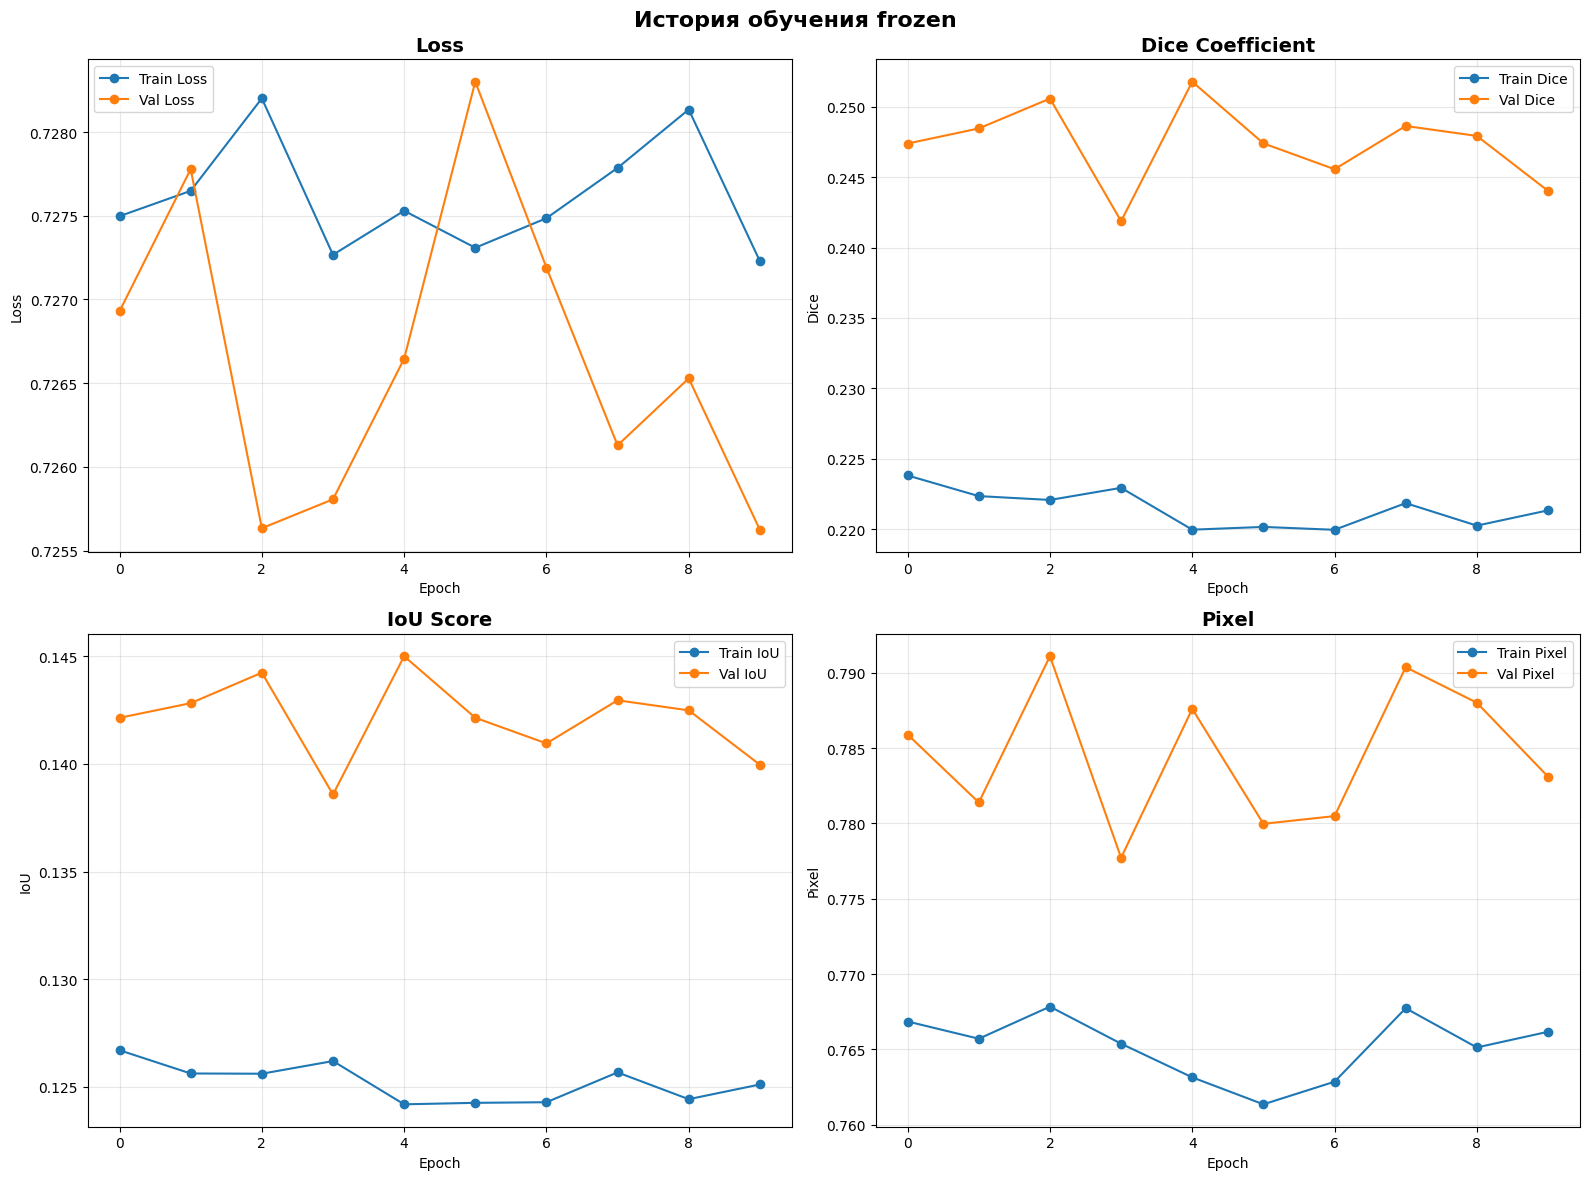

Train Loss: 0.7272
Val Loss: 0.7256
Train Dice: 0.2213
Val Dice: 0.2440
Train IoU: 0.1251
Val IoU: 0.1400
Val Accuracy: 0.7831


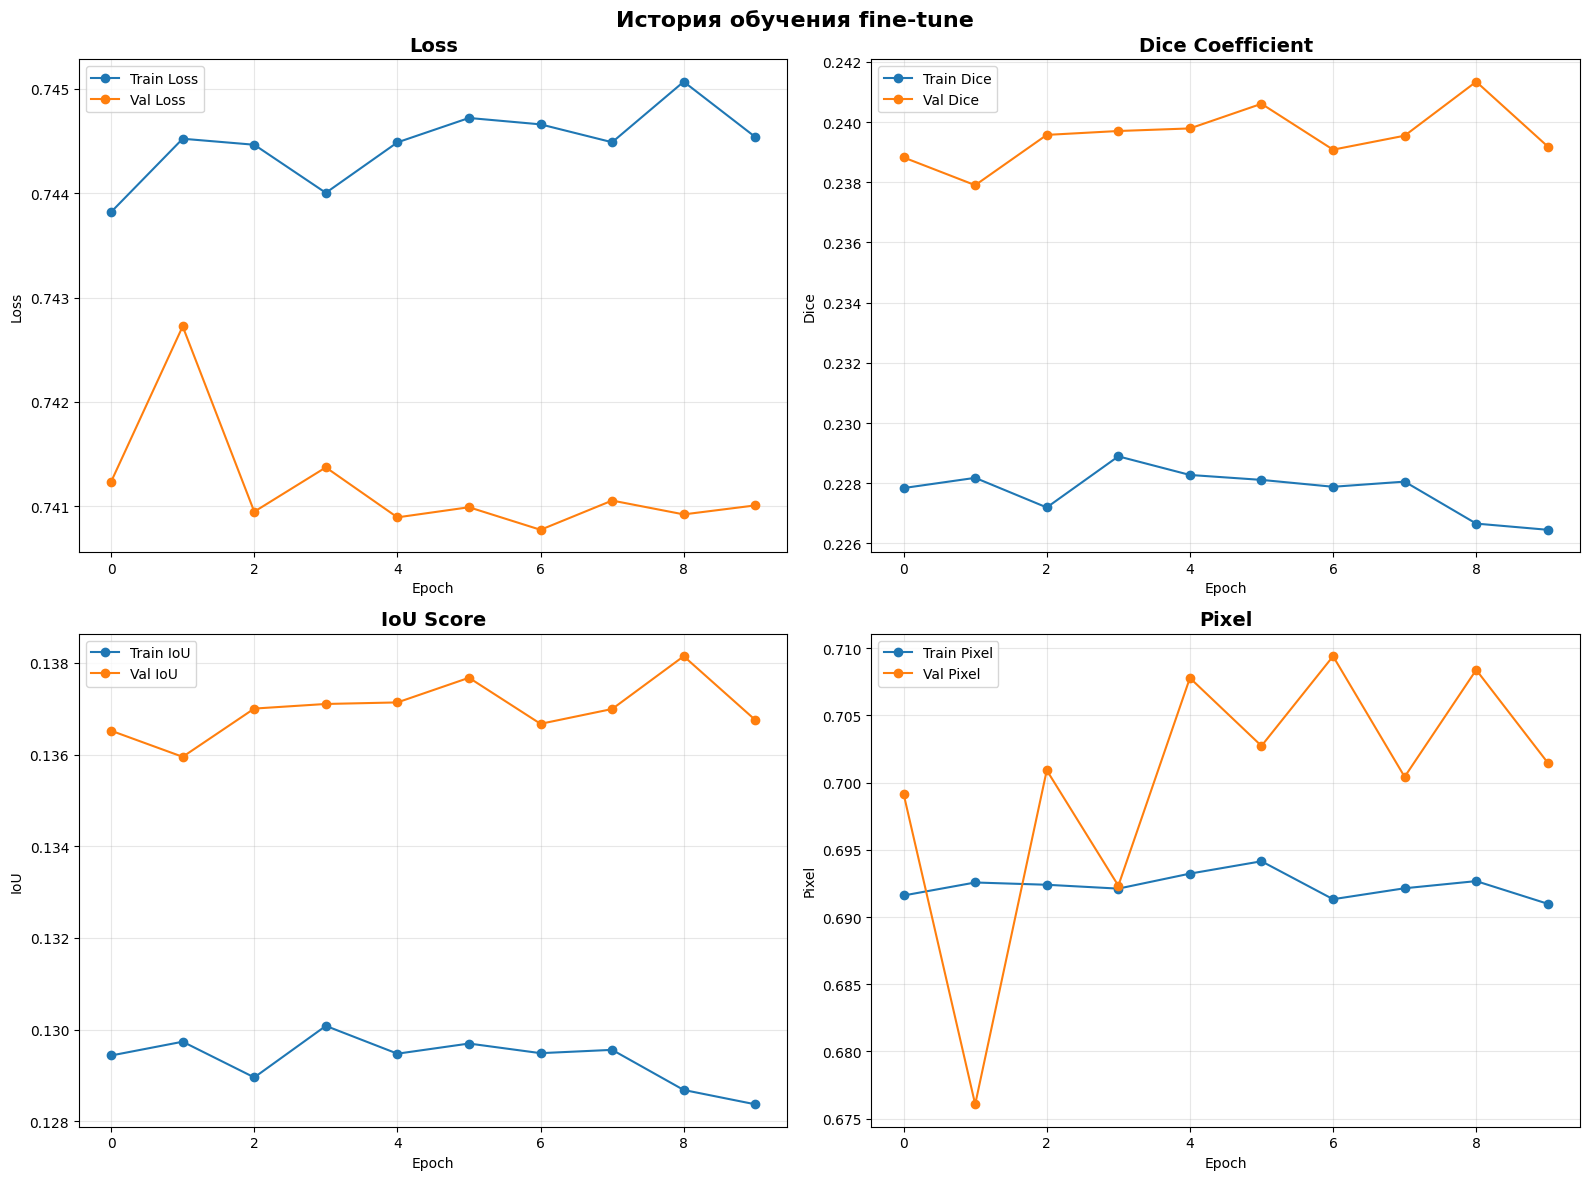

Train Loss: 0.7445
Val Loss: 0.7410
Train Dice: 0.2265
Val Dice: 0.2392
Train IoU: 0.1284
Val IoU: 0.1368
Val Accuracy: 0.7015


In [48]:
def plot_training_history(history, name_title):

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Dice Coefficient
    axes[0, 1].plot(history['train_dice'], label='Train Dice', marker='o')
    axes[0, 1].plot(history['val_dice'], label='Val Dice', marker='o')
    axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # IoU Score
    axes[1, 0].plot(history['train_iou'], label='Train IoU', marker='o')
    axes[1, 0].plot(history['val_iou'], label='Val IoU', marker='o')
    axes[1, 0].set_title('IoU Score', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 1].plot(history['train_acc'], label='Train Pixel', marker='o')
    axes[1, 1].plot(history['val_acc'], label='Val Pixel', marker='o')
    axes[1, 1].set_title('Pixel', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Pixel')
    # axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(name_title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


    print(f"Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"Train Dice: {history['train_dice'][-1]:.4f}")
    print(f"Val Dice: {history['val_dice'][-1]:.4f}")
    print(f"Train IoU: {history['train_iou'][-1]:.4f}")
    print(f"Val IoU: {history['val_iou'][-1]:.4f}")
    print(f"Val Accuracy: {history['val_acc'][-1]:.4f}")


plot_training_history(history_frozen, 'История обучения frozen')
plot_training_history(history_fine_tune, 'История обучения fine-tune')

Визуализация предсказаний

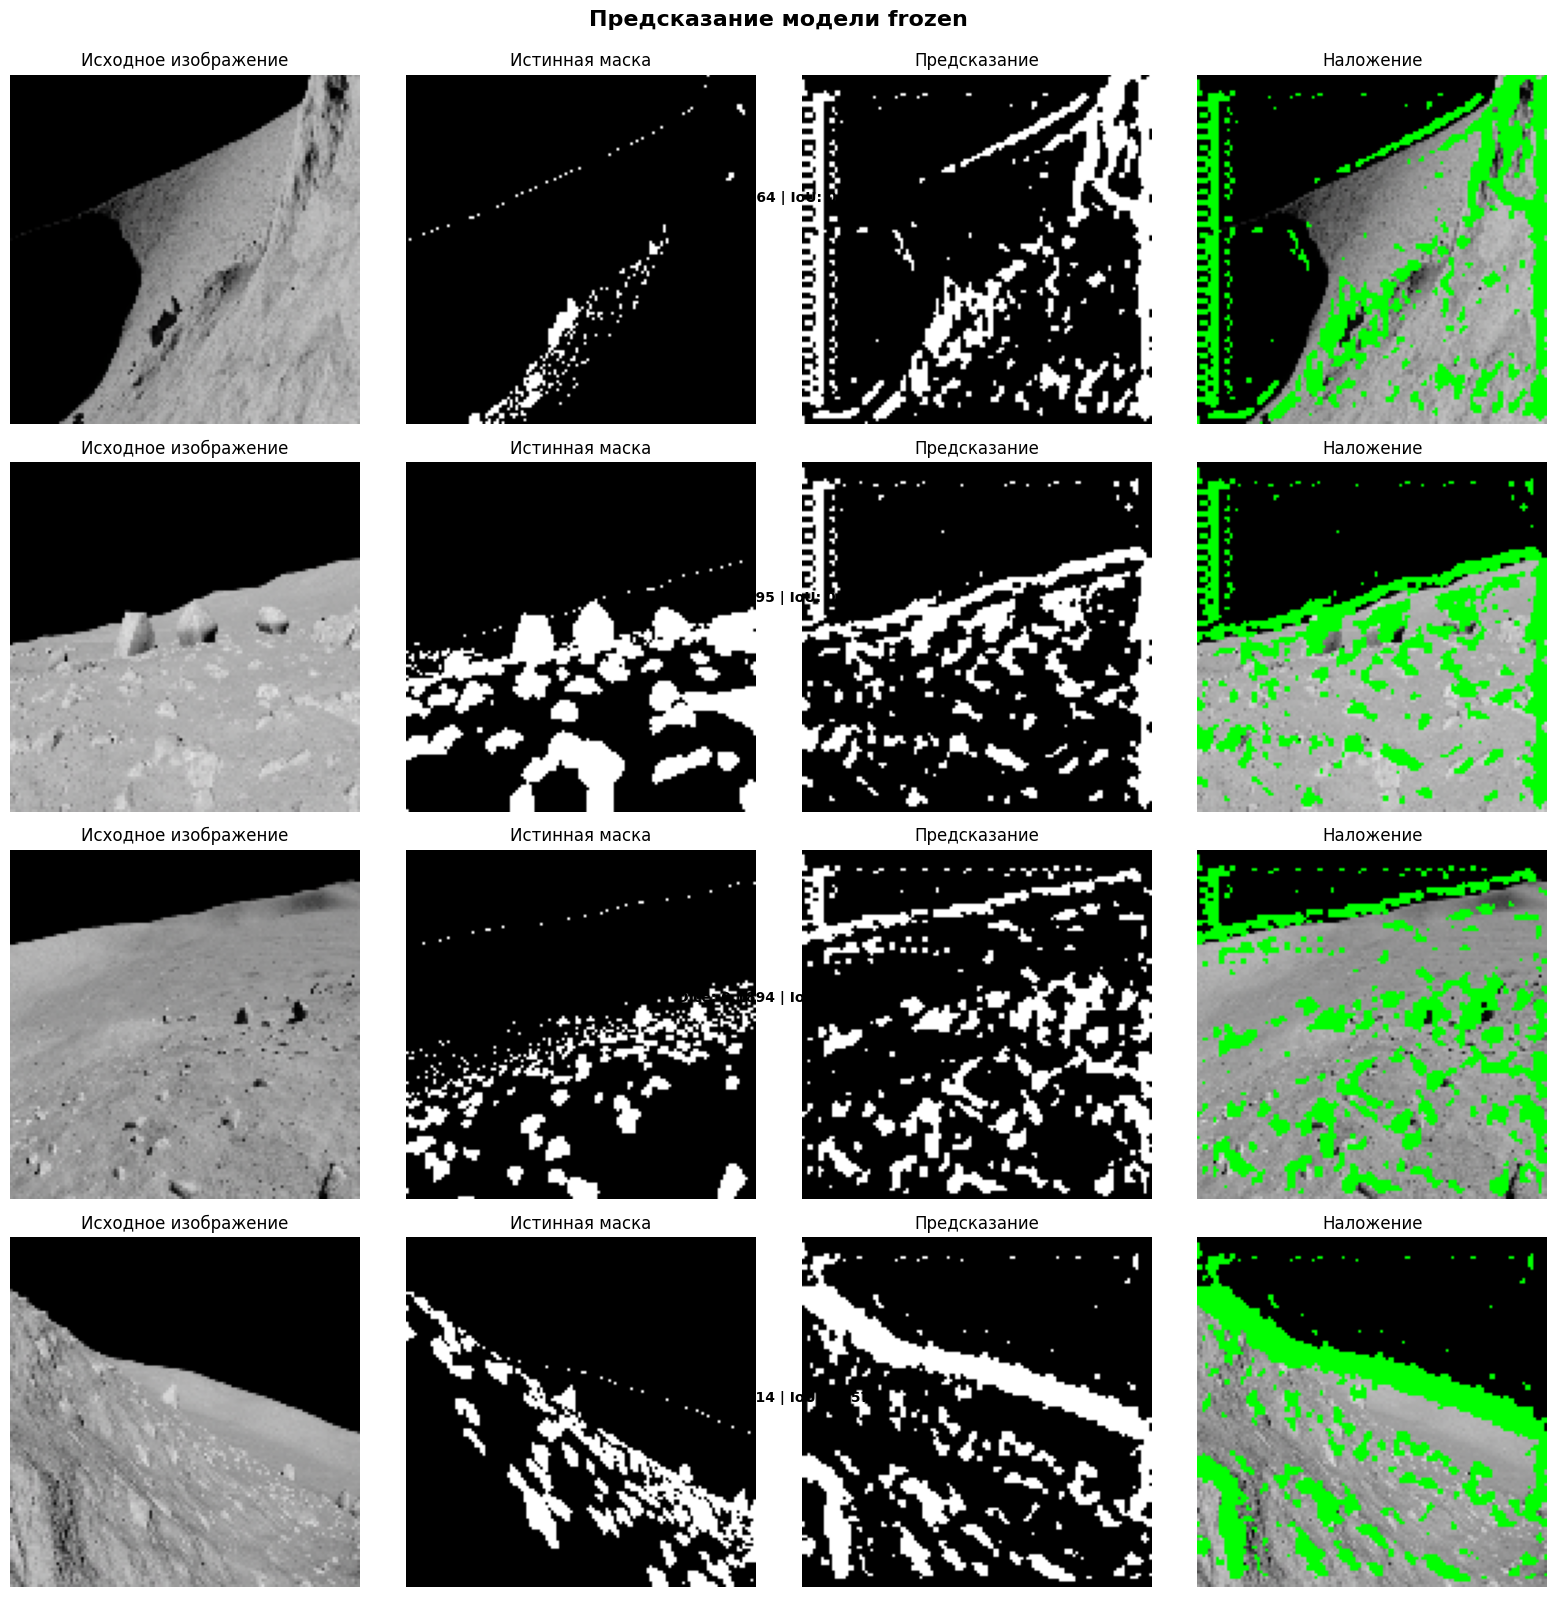

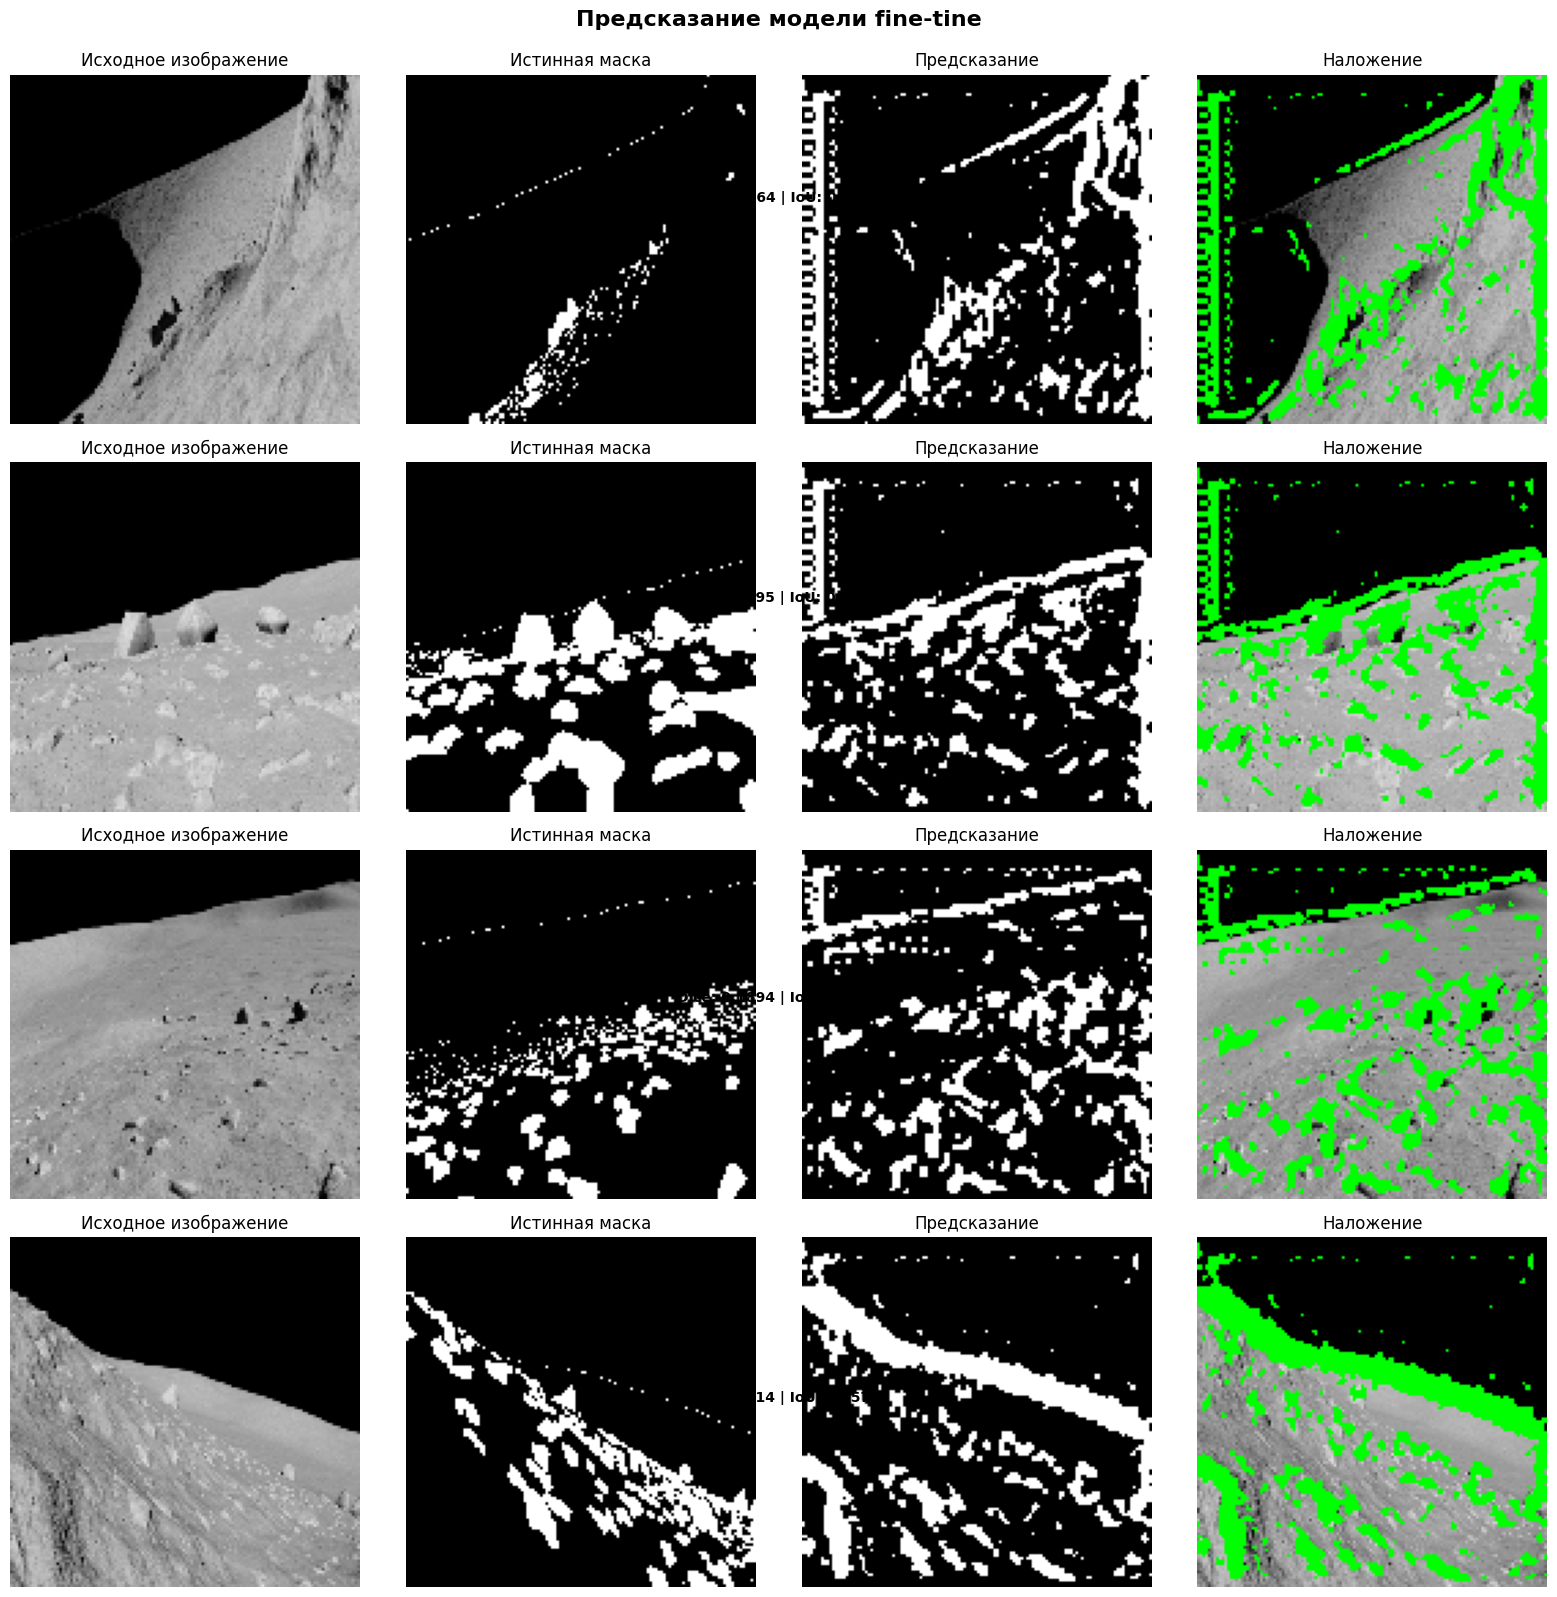

In [49]:
def visualize_predictions(model, dataloader, device, name_title, num_samples=4):

    model.eval()

    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = torch.sigmoid(outputs)
        predictions = (predictions > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    predictions = predictions.cpu()

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    for i in range(min(num_samples, len(images))):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        mask_true = masks[i, :,:].numpy()
        mask_pred = predictions[i, 0].numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Исходное изображение', fontsize=12)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_true, cmap='gray')
        axes[i, 1].set_title('Истинная маска', fontsize=12)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(mask_pred, cmap='gray')
        axes[i, 2].set_title('Предсказание', fontsize=12)
        axes[i, 2].axis('off')

        overlay = img.copy()
        overlay[mask_pred > 0.5] = [0, 1, 0]

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Наложение', fontsize=12)
        axes[i, 3].axis('off')

        dice = dice_coefficient(outputs[i:i+1], masks[i:i+1])
        iou = iou_score(outputs[i:i+1], masks[i:i+1])

        fig.text(0.5, 1 - (i + 0.5) / num_samples,
                f'Dice: {dice:.4f} | IoU: {iou:.4f}',
                ha='center', fontsize=10, fontweight='bold')

    plt.suptitle(name_title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

visualize_predictions(unet_a, val_loader, device, name_title='Предсказание модели frozen', num_samples=4)
visualize_predictions(unet_a, val_loader, device, name_title='Предсказание модели fine-tine', num_samples=4)

Сравнительная таблица

In [55]:
comparison_data = {
    'Model': [
        'Basic U-Net',
        'U-Net + Frozen Encoder',
        'U-Net + Fine-tuned Encoder'
    ],
    'Parameters (M)': [
        f'{total_params/1e6:.2f}',
        f'{total_params_frozen/1e6:.2f}',
        f'{total_params_fine_tune/1e6:.2f}'
    ],
    'Trainable Params (M)': [
        f'{total_params/1e6:.2f}',
        f'{trainable_params_frozen/1e6:.2f}',
        f'{trainable_params_fine_tune/1e6:.2f}'
    ],
    'Best Val IoU': [
        f'{history["val_iou"][-1]:.4f}',
        f'{history_frozen["val_iou"][-1]:.4f}',
        f'{history_fine_tune["val_iou"][-1]:.4f}'
    ],
    'Best Val Dice': [
        f'{history["val_dice"][-1]:.4f}',
        f'{history_frozen["val_dice"][-1]:.4f}',
        f'{history_fine_tune["val_dice"][-1]:.4f}'
    ],
    'Best Val Pixel Acc': [
        f'{history["val_acc"][-1]:.4f}',
        f'{history_frozen["val_acc"][-1]:.4f}',
        f'{history_fine_tune["val_acc"][-1]:.4f}'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print('Сравнительная таблица')
print(df_comparison.to_string(index=False))

Сравнительная таблица
                     Model Parameters (M) Trainable Params (M) Best Val IoU Best Val Dice Best Val Pixel Acc
               Basic U-Net          31.04                31.04       0.4214        0.5900             0.9098
    U-Net + Frozen Encoder           2.40                 1.16       0.1400        0.2440             0.7831
U-Net + Fine-tuned Encoder           2.40                 1.16       0.1368        0.2392             0.7015
